In [216]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/Baseline Correction"))
from load_data import read_data, create_combined_dataset
from baseline_correct import baseline_roy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


from scipy.stats import f_oneway
import seaborn as sns


In [217]:
path = ["../ALLDataGross/allKgData",
    "../ALLDataGross/BlindData",
    "../ALLDataGross/healthyCohort"
]
normVP = [[504, 425, 451, 454, 450, 474, 451, 471, 540, 467,
    550, 468, 481, 450, 515, 441, 452, 462, 453, 450, 452, 
    490, 504, 520, 525, 498, 542, 527, 550],
        [505, 503, 478, 453, 460, 494, 410, 413, 479, 489, 
    473, 464, 445, 499, 406, 455, 481, 388, 428, 466, 463, 
    520, 461],
    [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]]
infoP = [["H", "PC", "PC", "H", "PC", "BC", "PC", "PC", "BC", "BC", 
    "PC", "PC", "PC", "PC", "H", "H","PC", "PC", "KC", "PC", "KC", 
    "PC", "BC", "BC", "PC", "KC", "PC", "PC", "PC"],
        ["H", "H" ,"H" ,"H", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG" ,
     "KG", "KG", "KG", "KG", "KG" ,"KG", "KG" ,"KG", "KG", "KG"],
          ["F", "M", "M", "F", "F", "F", "F", "M", "M", "M", 
    "M", "F", "M", "M", "F", "M" ,"M", "M", "M", "M", 
    "M", "M" ]
]
df = create_combined_dataset(path,normVP,infoP)

df['intensity_baseline_corrected'] = None
for idx, row in df.iterrows():
    df.at[idx, "intensity_baseline_corrected"] = baseline_roy(x=row["wavenumber"], y=row["intensity"], norm_factor_i=row['normVP'])
    print(f"{idx} done!")
print("baseline corrected!")

Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/allKgData/20190801-02-023.dpt'), PosixPath('../ALLDataGross/allKgData/dataLoadKGall.m'), PosixPath('../ALLDataGross/allKgData/20190801-01-022.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-04-012.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-03-024.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-05-004.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-12-010.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-10-018.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-05-013.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-07-028.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-04-003.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-09-017.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-03-002.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-06-014.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-02-001.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-13-021.dpt'), PosixP

In [218]:
print(df["category"].value_counts())
print(df["infoP"].value_counts()) 

df = df[df["category"]!= "blinddata"]
print(df["category"].unique())

category
allkgdata      29
blinddata      23
healthydata    22
Name: count, dtype: int64
infoP
KG    19
PC    17
M     15
H      8
F      7
BC     5
KC     3
Name: count, dtype: int64
['allkgdata' 'healthydata']


In [219]:
df["class"] = df["infoP"].apply(lambda x: "H" if x in ["M", "F", "H"] else x)

In [220]:
df["class"].value_counts()

class
H     26
PC    17
BC     5
KC     3
Name: count, dtype: int64

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 73
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    51 non-null     object
 1   original_filename             51 non-null     object
 2   category                      51 non-null     object
 3   normVP                        51 non-null     int64 
 4   infoP                         51 non-null     object
 5   wavenumber                    51 non-null     object
 6   intensity                     51 non-null     object
 7   spectrum_length               51 non-null     int64 
 8   intensity_baseline_corrected  51 non-null     object
 9   class                         51 non-null     object
dtypes: int64(2), object(8)
memory usage: 4.4+ KB


In [222]:
import numpy as np


intensity_key = "intensity_baseline_corrected"

# Build (n_samples, n_wavenumbers) matrix for full 500–4000 cm^-1 window
wn = df.iloc[0]["wavenumber"]
mask_whole = (wn >= 500) & (wn <= 4000)

X_whole = np.stack(df[intensity_key].apply(lambda y: y[mask_whole]).values)
X_whole = X_whole[df["class"].isin(["PC", "H"])]
X_whole.shape
# X_whole has shape (n_patients, n_points)

(43, 14517)

In [223]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# import numpy as np

# scale features (columns)
scaler_whole = StandardScaler()
X_whole_scaled = scaler_whole.fit_transform(X_whole)

# choose enough PCs (e.g. all, or say 50; adjust as you like)
pca_whole = PCA(n_components=min(6, X_whole_scaled.shape[1]))
X_whole_pcs = pca_whole.fit_transform(X_whole_scaled)

evr_whole = pca_whole.explained_variance_ratio_
cum_evr_whole = np.cumsum(evr_whole)

# define K for your thesis, e.g. 80% threshold:
threshold = 0.80
K_WHOLE = np.argmax(cum_evr_whole >= threshold) + 1

VAR_EXPLAINED_WHOLE = cum_evr_whole[K_WHOLE - 1] * 100
VAR_FIRST3_WHOLE = evr_whole[:3].sum() * 100

print("K_WHOLE:", K_WHOLE)
print("VAR_EXPLAINED_WHOLE (%):", VAR_EXPLAINED_WHOLE)
print("VAR_FIRST3_WHOLE (%):", VAR_FIRST3_WHOLE)

K_WHOLE: 2
VAR_EXPLAINED_WHOLE (%): 88.47758039958865
VAR_FIRST3_WHOLE (%): 92.18698663618376


In [224]:
X_whole_pcs.shape


(43, 6)

### Binary Claaification

In [225]:
df_bin = df[df["class"].isin(["PC", "H"])].copy() #remove KC BC
y = (df_bin["class"] == "PC").astype(int).values
# len(y)

In [226]:
X = np.vstack(
    df_bin["intensity_baseline_corrected"]
        .apply(np.asarray)
        .values
)
# X shape: (n_samples, n_wavenumbers)
X.shape

(43, 14517)

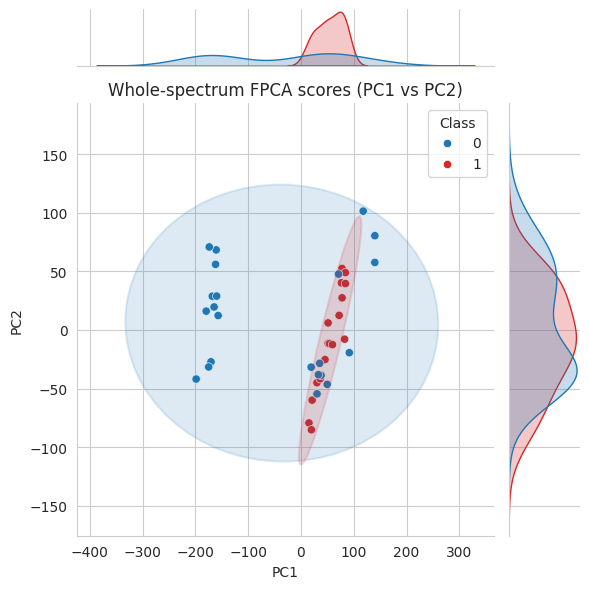

In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# REQUIRED:
# X_whole_pcs: array (n_samples, >=2) from whole-spectrum PCA transform
# y: array-like length n_samples with labels "H" and "PC"

df_scores = pd.DataFrame({
    "PC1": X_whole_pcs[:, 0],
    "PC2": X_whole_pcs[:, 1],
    "Class": y
})

palette = {0: "tab:blue", 1: "tab:red"}

# --- helper to draw 95% confidence ellipse (assumes approx normal scores) ---
def add_confidence_ellipse(ax, x, y, color, alpha=0.15, linewidth=1.5):
    x = np.asarray(x)
    y = np.asarray(y)
    cov = np.cov(x, y)
    mean = np.array([x.mean(), y.mean()])

    # eigen-decomposition
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # 95% chi-square quantile for 2 dof
    chi2_val = 5.991
    width, height = 2 * np.sqrt(vals * chi2_val)

    # angle of ellipse
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    from matplotlib.patches import Ellipse
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  facecolor=color, edgecolor=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ell)

sns.set_style("whitegrid")

g = sns.jointplot(
    data=df_scores, x="PC1", y="PC2", hue="Class",
    kind="scatter", palette=palette,
    height=6, space=0,
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.25),
)

# add ellipses to the main axes
ax = g.ax_joint
for cls, col in palette.items():
    sub = df_scores[df_scores["Class"] == cls]
    if len(sub) >= 3:
        add_confidence_ellipse(ax, sub["PC1"], sub["PC2"], color=col)

ax.set_title("Whole-spectrum FPCA scores (PC1 vs PC2)")
plt.tight_layout()

# Optional: save for LaTeX
# plt.savefig("figures/score_scatter_whole.png", dpi=300, bbox_inches="tight")
plt.show()

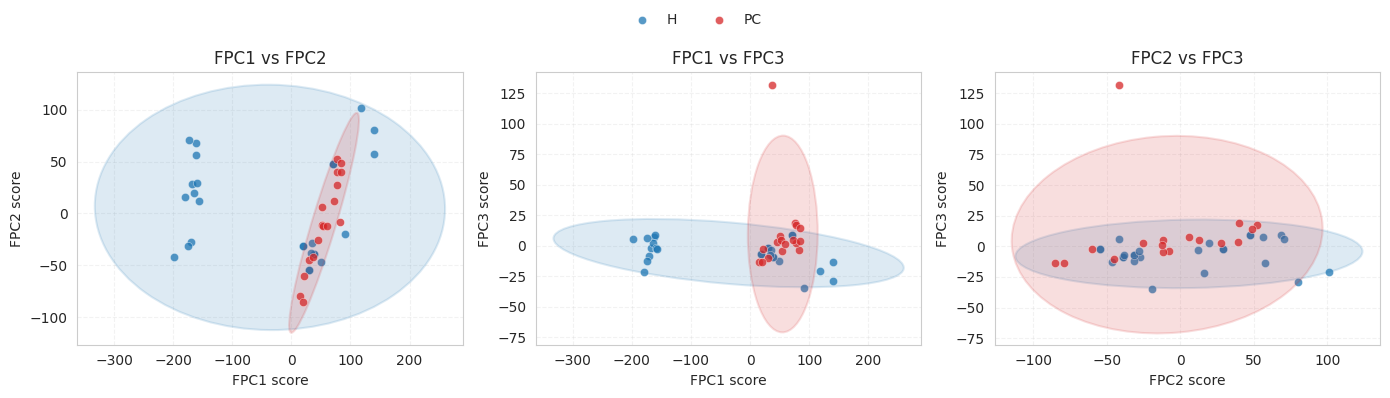

In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

# INPUTS:
# X_whole_pcs: (n_samples, >=3) whole-spectrum PCA/FPCA scores
# y: labels, either 0/1 or "H"/"PC"

y = np.asarray(y)
label_map = {0: "H", 1: "PC", "H": "H", "PC": "PC"}
y_str = pd.Series(y).map(label_map)

df_new = pd.DataFrame({
    "FPC1": X_whole_pcs[:, 0],
    "FPC2": X_whole_pcs[:, 1],
    "FPC3": X_whole_pcs[:, 2],
    "Class": y_str
})

palette = {"H": "tab:blue", "PC": "tab:red"}

def add_confidence_ellipse(ax, x, y, color, alpha=0.15, linewidth=1.5):
    x = np.asarray(x); y = np.asarray(y)
    if x.size < 3:
        return
    cov = np.cov(x, y)
    mean = np.array([x.mean(), y.mean()])

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    chi2_val = 5.991  # 95% quantile for 2 dof
    width, height = 2 * np.sqrt(vals * chi2_val)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  facecolor=color, edgecolor=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ell)

sns.set_style("whitegrid")

pairs = [("FPC1", "FPC2"), ("FPC1", "FPC3"), ("FPC2", "FPC3")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (xcol, ycol) in zip(axes, pairs):
    # scatter
    for cls, col in palette.items():
        sub = df_new[df_new["Class"] == cls]
        ax.scatter(sub[xcol], sub[ycol], s=35, alpha=0.75,
                   color=col, edgecolor="white", linewidth=0.4, label=cls)

        # ellipse
        add_confidence_ellipse(ax, sub[xcol], sub[ycol], color=col)

    ax.set_xlabel(f"{xcol} score")
    ax.set_ylabel(f"{ycol} score")
    ax.set_title(f"{xcol} vs {ycol}")
    ax.grid(alpha=0.25, linestyle="--")

# one legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.savefig("figures/score_pairwise.png", dpi=300, bbox_inches="tight")
plt.show()

In [229]:
# t = np.asarray(df_bin.iloc[0]["wavenumber"])
# Each row = one function in X
# Columns correspond to same grid points

X_mean = X.mean(axis=0)
X_centered = X - X_mean

In [230]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver="full")
scores = pca.fit_transform(X_centered)
cumvar = np.cumsum(pca.explained_variance_ratio_)
K = np.searchsorted(cumvar, 0.95) + 1

scores_K = scores[:, :K]
# scores_K

In [231]:
from sklearn.svm import SVC

clf = SVC(kernel="rbf", C=1.0, gamma="scale")
clf.fit(scores_K, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [232]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import balanced_accuracy_score

loo = LeaveOneOut()
y_true, y_pred, decisions = [], [], []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Center on training data only
    mean_tr = X_tr.mean(axis=0)
    X_tr_c = X_tr - mean_tr
    X_te_c = X_te - mean_tr

    pca = PCA()
    scores_tr = pca.fit_transform(X_tr_c)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    K = np.searchsorted(cumvar, 0.95) + 1
    print(K)
    scores_tr = scores_tr[:, :K]
    scores_te = pca.transform(X_te_c)[:, :K]

    

    clf = SVC(kernel="rbf", C=100)#, class_weight="balanced")
    clf.fit(scores_tr, y_tr)

    decision = clf.decision_function(scores_te)[0]
    pred = (decision> 0).astype(int)

    decisions.append(decision)
    y_pred.append(pred)
    y_true.append(y_te[0])

# bal_acc = balanced_accuracy_score(y_true, y_pred)
results_whole = {
    "y_true": np.array(y_true),
    "y_pred": np.array(y_pred),
    "decisions": np.array(decisions),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
}


6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
5
6
6
6
6
6
6
6
6
6
6
6


In [233]:
results_whole

{'y_true': array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'y_pred': array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'decisions': array([-1.03012673,  6.22653483,  1.0743361 , -0.46896814, -1.82840828,
         1.89290828,  0.7318998 ,  2.39291061,  0.2603138 , -1.34293488,
        -1.62989232, -0.21697223, -0.93706467,  0.89103275,  1.08174323,
         6.34540939,  0.94725744,  1.77629027,  0.57620189,  1.52527845,
        -0.3885839 , -1.42989888, -1.34959736, -1.35016345, -1.47079807,
        -1.32989257, -1.44032021, -1.36107262, -1.30725512, -1.30110701,
        -1.27292681,  0.55534445, -0.19382744, -0.62053473, -1.50589034,
        -0.60793464, -1.15416814, -1.03012673, -0.46896814, -0.21697223,
        -0.93706467, -1.44138542, -0.60488633]),
 'balanced_accuracy': 0.8631221719457014

In [234]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_values(decisions, y_true, title):
    y_num = np.array([1 if y == "PC" else 0 for y in y_true])

    assert len(decisions) == len(y_true)
    
    plt.figure(figsize=(7,4))
    for cls, label in [(1, "PC"), (0, "H")]:
        idx = y_num == cls
        plt.scatter(
            np.where(idx)[0],
            decisions[idx],
            label=label,
            alpha=0.8
        )

    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Sample index")
    plt.ylabel("Decision value f(x)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


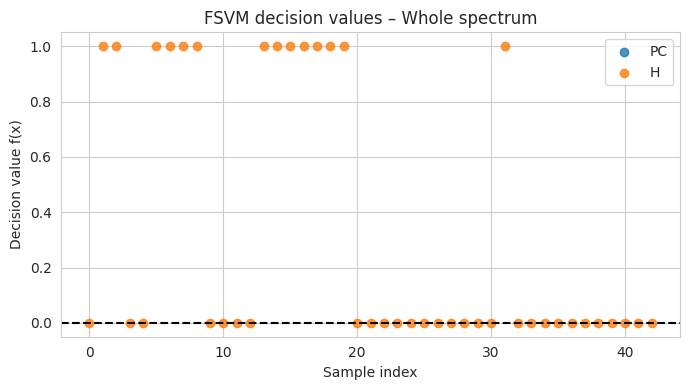

In [235]:
plot_decision_values(
    decisions=results_whole["y_pred"],
    y_true=results_whole["y_true"],
    title="FSVM decision values – Whole spectrum"
)


In [236]:
def plot_margin_histogram(decisions, y_true, title):
    y_num = np.array([1 if y == "PC" else -1 for y in y_true])

    plt.figure(figsize=(6,4))
    plt.hist(decisions[y_num == 1], bins=10, alpha=0.7, label="PC")
    plt.hist(decisions[y_num == -1], bins=10, alpha=0.7, label="H")
    plt.axvline(0, color="black", linestyle="--")
    plt.xlabel("Decision value")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [237]:
decisions=results_whole["decisions"]
y_true=results_whole["y_true"]
decisions, y_true


(array([-1.03012673,  6.22653483,  1.0743361 , -0.46896814, -1.82840828,
         1.89290828,  0.7318998 ,  2.39291061,  0.2603138 , -1.34293488,
        -1.62989232, -0.21697223, -0.93706467,  0.89103275,  1.08174323,
         6.34540939,  0.94725744,  1.77629027,  0.57620189,  1.52527845,
        -0.3885839 , -1.42989888, -1.34959736, -1.35016345, -1.47079807,
        -1.32989257, -1.44032021, -1.36107262, -1.30725512, -1.30110701,
        -1.27292681,  0.55534445, -0.19382744, -0.62053473, -1.50589034,
        -0.60793464, -1.15416814, -1.03012673, -0.46896814, -0.21697223,
        -0.93706467, -1.44138542, -0.60488633]),
 array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

## Binary FSVM on Whole Spectrum - cleaner code

In [238]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import balanced_accuracy_score


In [239]:
df.head()

,patient_id,original_filename,category,normVP,infoP,wavenumber,intensity,spectrum_length,intensity_baseline_corrected,class
0,allkg_1,20190405-02-001,allkgdata,504,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05628, -0.05859, -0.05958, -0.05698, -0.05...",14517,"[-0.02235369230769231, -0.02957092307692308, -...",H
1,allkg_2,20190405-03-002,allkgdata,425,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.05227, -0.05274, -0.05296, -0.05487, -0.05...",14517,"[-0.01996602884615385, -0.027064038461538466, ...",PC
2,allkg_3,20190405-04-003,allkgdata,451,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06495, -0.06361, -0.06284, -0.06221, -0.06...",14517,"[-0.024317278846153843, -0.032105038461538456,...",PC
3,allkg_4,20190405-05-004,allkgdata,454,H,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.0566, -0.05447, -0.0543, -0.05597, -0.0578...",14517,"[-0.019800384615384616, -0.026569846153846152,...",H
4,allkg_5,20190405-06-005,allkgdata,450,PC,"[500.02826, 500.26936, 500.51045, 500.75154, 5...","[-0.06155, -0.05976, -0.05649, -0.05513, -0.05...",14517,"[-0.022687605769230765, -0.02942280769230769, ...",PC


In [240]:
df_bin = df[df["class"].isin(["PC", "H"])].copy()

y = (df_bin["class"] == "PC").astype(int).values

X = np.vstack(
    df_bin["intensity_baseline_corrected"]
        .apply(np.asarray)
        .values
)

# X.shape: (n_samples, n_wavenumbers)
print("X shape:", X.shape)


X shape: (43, 14517)


In [241]:
y

array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [242]:
X_mean = X.mean(axis=0)
X_centered = X - X_mean

pca = PCA(svd_solver="full")
scores = pca.fit_transform(X_centered)

cumvar = np.cumsum(pca.explained_variance_ratio_)
K = np.searchsorted(cumvar, 0.95) + 1

scores_K = scores[:, :K]
print("Number of PCs retained:", K)


Number of PCs retained: 6


In [243]:
clf = SVC(kernel="rbf", C=1.0, gamma="scale")
clf.fit(scores_K, y)
print("Total support vectors:", clf.n_support_.sum())

Total support vectors: 31


In [244]:
loo = LeaveOneOut()

y_true = []
y_pred = []
decisions = []

for train_idx, test_idx in loo.split(X):

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Center using training mean only
    mean_tr = X_tr.mean(axis=0)
    X_tr_c = X_tr - mean_tr
    X_te_c = X_te - mean_tr

    # PCA on training data only
    pca = PCA()
    scores_tr = pca.fit_transform(X_tr_c)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    K = np.searchsorted(cumvar, 0.95) + 1

    scores_tr = scores_tr[:, :K]
    scores_te = pca.transform(X_te_c)[:, :K]

    # SVM
    clf = SVC(kernel="rbf", C=100) 
    clf.fit(scores_tr, y_tr)

    decision = clf.decision_function(scores_te)[0]
    pred = (decision > 0).astype(int)

    decisions.append(decision)
    y_pred.append(pred)
    y_true.append(y_te[0])


In [245]:
results_whole = {
    "y_true": np.array(y_true),
    "y_pred": np.array(y_pred),
    "decisions": np.array(decisions),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
}

results_whole


{'y_true': array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'y_pred': array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'decisions': array([-1.03012673,  6.22653483,  1.0743361 , -0.46896814, -1.82840828,
         1.89290828,  0.7318998 ,  2.39291061,  0.2603138 , -1.34293488,
        -1.62989232, -0.21697223, -0.93706467,  0.89103275,  1.08174323,
         6.34540939,  0.94725744,  1.77629027,  0.57620189,  1.52527845,
        -0.3885839 , -1.42989888, -1.34959736, -1.35016345, -1.47079807,
        -1.32989257, -1.44032021, -1.36107262, -1.30725512, -1.30110701,
        -1.27292681,  0.55534445, -0.19382744, -0.62053473, -1.50589034,
        -0.60793464, -1.15416814, -1.03012673, -0.46896814, -0.21697223,
        -0.93706467, -1.44138542, -0.60488633]),
 'balanced_accuracy': 0.8631221719457014

### K Fold cross validation

In [246]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score
from sklearn.svm import SVC


def repeated_stratified_kfold_fsvm(
        X,
        y,
        feature_transform=None,
        k_values=(13, 14, 15),
        n_repeats=100,
        C=1.0,
        class_weight="balanced",
        random_state=42
    ):
    """
    Repeated Stratified k-fold CV for FSVM classification.

    Parameters
    ----------
    X : array-like (n_samples, n_features)
        Input feature matrix (FPCA scores or spectral features).
        
    y : array-like (n_samples,)
        Class labels.

    feature_transform : callable or None
        Function that performs transformations like FPCA.
        Must return (X_train_transformed, X_test_transformed).

    k_values : tuple
        Values of k for Stratified k-fold (default: 5 and 10).

    n_repeats : int
        Number of repetitions of CV.

    C : float
        SVM regularization parameter.

    class_weight : dict or "balanced"
        Weighting for class imbalance.

    random_state : int
        Random seed.

    Returns
    -------
    results : dict
        Dictionary containing performance statistics.
    """

    rng = np.random.RandomState(random_state)

    results = {k: {"accuracy": [], "balanced_accuracy": [], 
                   "sensitivity": [], "specificity": []}
               for k in k_values}

    for k in k_values:

        for r in range(n_repeats):

            skf = StratifiedKFold(
                n_splits=k,
                shuffle=True,
                random_state=rng.randint(0, 100000)
            )

            fold_acc = []
            fold_bal_acc = []
            fold_sens = []
            fold_spec = []

            for train_idx, test_idx in skf.split(X, y):

                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                # ---- Feature transformation inside fold (e.g. FPCA)
                if feature_transform is not None:
                    X_train, X_test = feature_transform(X_train, X_test)

                # ---- Linear SVM (FSVM in score space)
                model = SVC(
                    kernel="linear",
                    C=C,
                    class_weight=class_weight
                )

                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                bal_acc = balanced_accuracy_score(y_test, y_pred)

                sens = recall_score(y_test, y_pred, pos_label=1)
                spec = recall_score(y_test, y_pred, pos_label=0)

                fold_acc.append(acc)
                fold_bal_acc.append(bal_acc)
                fold_sens.append(sens)
                fold_spec.append(spec)

            results[k]["accuracy"].append(np.mean(fold_acc))
            results[k]["balanced_accuracy"].append(np.mean(fold_bal_acc))
            results[k]["sensitivity"].append(np.mean(fold_sens))
            results[k]["specificity"].append(np.mean(fold_spec))

    return results

res = repeated_stratified_kfold_fsvm(X, y, feature_transform=None, n_repeats=100, C=1.0, class_weight="balanced", random_state=42)

In [247]:
for k, metrics in res.items():
    
    print(f"\n{k}-Fold CV")
    
    print("Accuracy:", np.mean(metrics["accuracy"]))
    print("Balanced Accuracy:", np.mean(metrics["balanced_accuracy"]))
    print("Sensitivity:", np.mean(metrics["sensitivity"]))
    print("Specificity:", np.mean(metrics["specificity"]))


13-Fold CV
Accuracy: 0.8149358974358973
Balanced Accuracy: 0.7959615384615385
Sensitivity: 0.7057692307692308
Specificity: 0.8861538461538464

14-Fold CV
Accuracy: 0.8119047619047616
Balanced Accuracy: 0.7953571428571431
Sensitivity: 0.6992857142857142
Specificity: 0.8914285714285713

15-Fold CV
Accuracy: 0.816888888888889
Balanced Accuracy: 0.7966666666666665
Sensitivity: 0.7033333333333335
Specificity: 0.8900000000000002


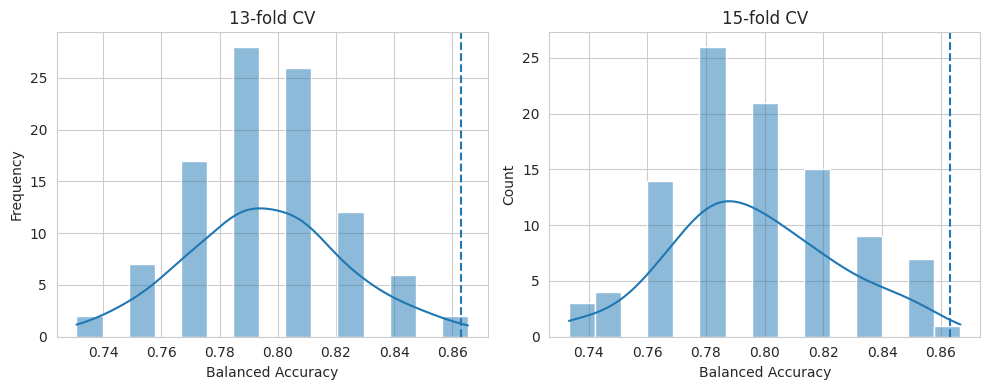

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_kfold_distribution(results, loocv_balacc):

    balacc_5 = results[13]["balanced_accuracy"]
    balacc_10 = results[15]["balanced_accuracy"]

    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    # ---- 5-fold plot
    sns.histplot(balacc_5, bins=15, kde=True, ax=axes[0])
    axes[0].axvline(loocv_balacc, linestyle="--")
    axes[0].set_title("13-fold CV")
    axes[0].set_xlabel("Balanced Accuracy")
    axes[0].set_ylabel("Frequency")

    # ---- 10-fold plot
    sns.histplot(balacc_10, bins=15, kde=True, ax=axes[1])
    axes[1].axvline(loocv_balacc, linestyle="--")
    axes[1].set_title("15-fold CV")
    axes[1].set_xlabel("Balanced Accuracy")

    plt.tight_layout()
    plt.show()

plot_kfold_distribution(res, loocv_balacc=0.8631221719457014)

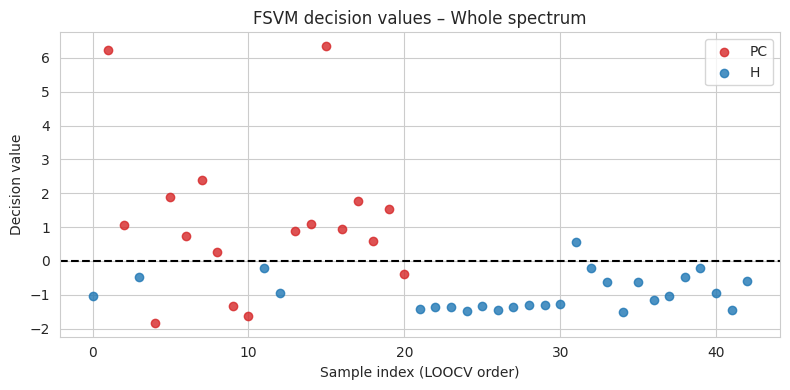

In [249]:
def plot_decision_values(decisions, y_true, title):
    decisions = np.asarray(decisions)
    y_true = np.asarray(y_true)

    plt.figure(figsize=(8, 4))

    for cls, label, color in [(1, "PC", "tab:red"), (0, "H", "tab:blue")]:
        idx = y_true == cls
        plt.scatter(
            np.where(idx)[0],
            decisions[idx],
            label=label,
            alpha=0.8,
            color=color
        )

    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Sample index (LOOCV order)")
    plt.ylabel("Decision value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_values(
    results_whole["decisions"],
    results_whole["y_true"],
    "FSVM decision values – Whole spectrum"
)


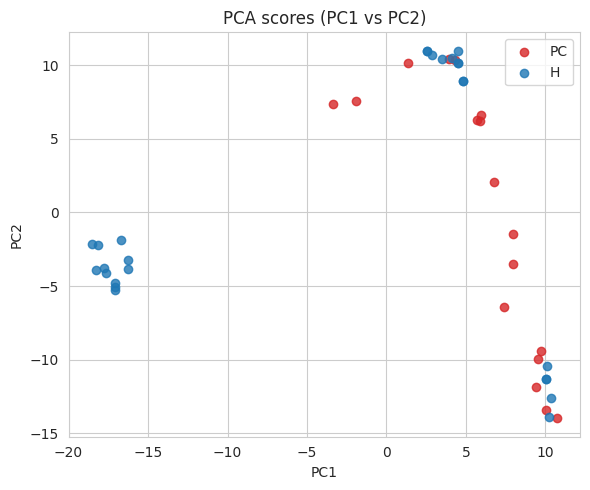

In [250]:
plt.figure(figsize=(6, 5))

for cls, label, color in [(1, "PC", "tab:red"), (0, "H", "tab:blue")]:
    idx = y == cls
    plt.scatter(
        scores[idx, 0],
        scores[idx, 1],
        label=label,
        alpha=0.8,
        color=color
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scores (PC1 vs PC2)")
plt.legend()
plt.tight_layout()
plt.show()


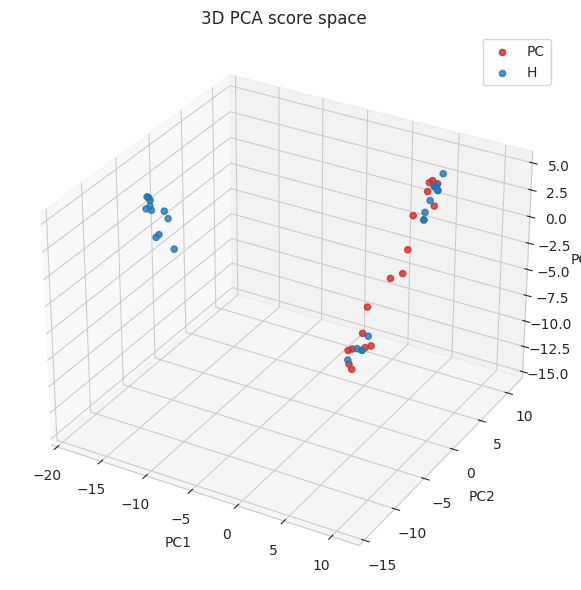

In [251]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for cls, label, color in [(1, "PC", "tab:red"), (0, "H", "tab:blue")]:
    idx = y == cls
    ax.scatter(
        scores[idx, 0],
        scores[idx, 1],
        scores[idx, 2],
        label=label,
        alpha=0.8,
        color=color
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA score space")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_5656/299977664.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


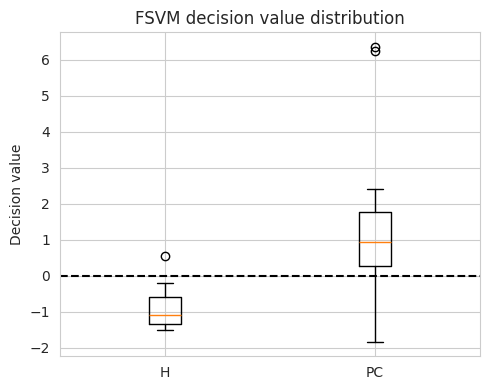

In [252]:
plt.figure(figsize=(5, 4))
plt.boxplot(
    [results_whole["decisions"][results_whole["y_true"] == 0],
     results_whole["decisions"][results_whole["y_true"] == 1]],
    labels=["H", "PC"]
)
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("Decision value")
plt.title("FSVM decision value distribution")
plt.tight_layout()
plt.show()


In [253]:
X.shape[1]

14517

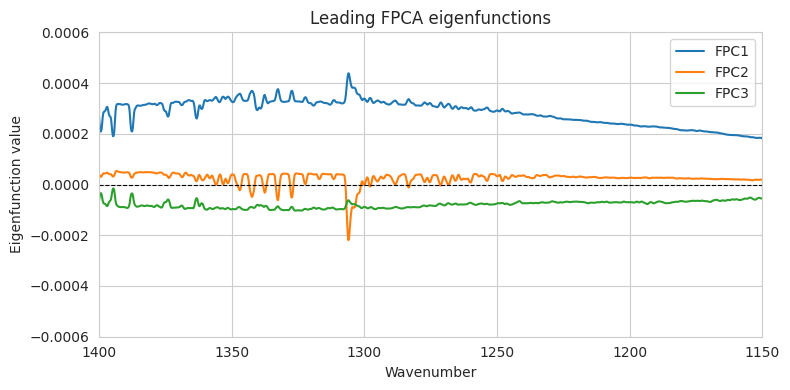

In [254]:
wavenumbers = np.linspace(500, 4000, X.shape[1])#np.arange(X.shape[1])

X_H = X[y == 0]
X_PC = X[y == 1]

mean_H = X_H.mean(axis=0)
mean_PC = X_PC.mean(axis=0)

phi = pca.components_[:3]  # first 3 eigenfunctions

plt.figure(figsize=(8, 4))
for k in range(3):
    plt.plot(wavenumbers, phi[k], label=f"FPC{k+1}")

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Wavenumber")
plt.ylabel("Eigenfunction value")
plt.xlim(1400, 1150)
plt.ylim(-0.0006, 0.0006)
plt.title("Leading FPCA eigenfunctions")
plt.legend()
plt.tight_layout()
plt.show()



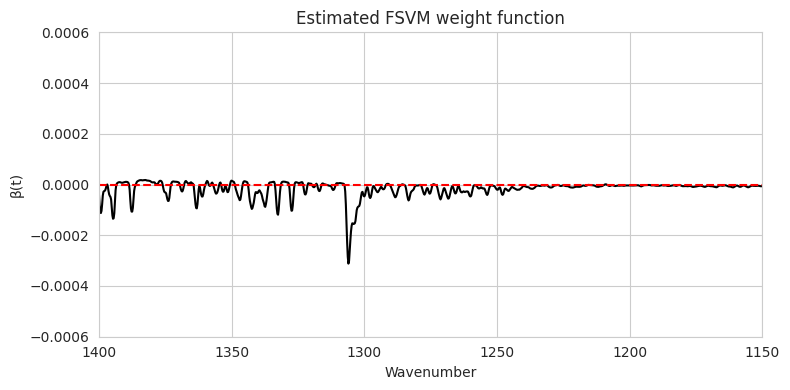

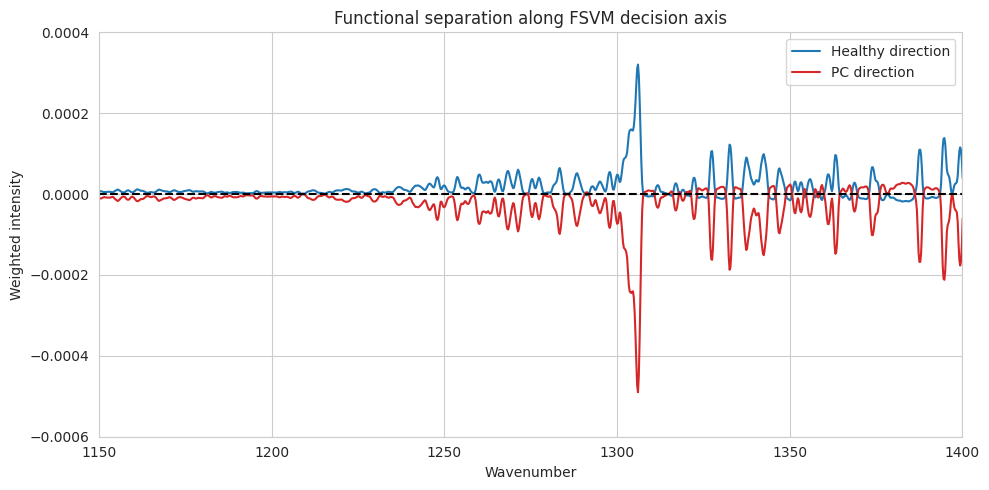

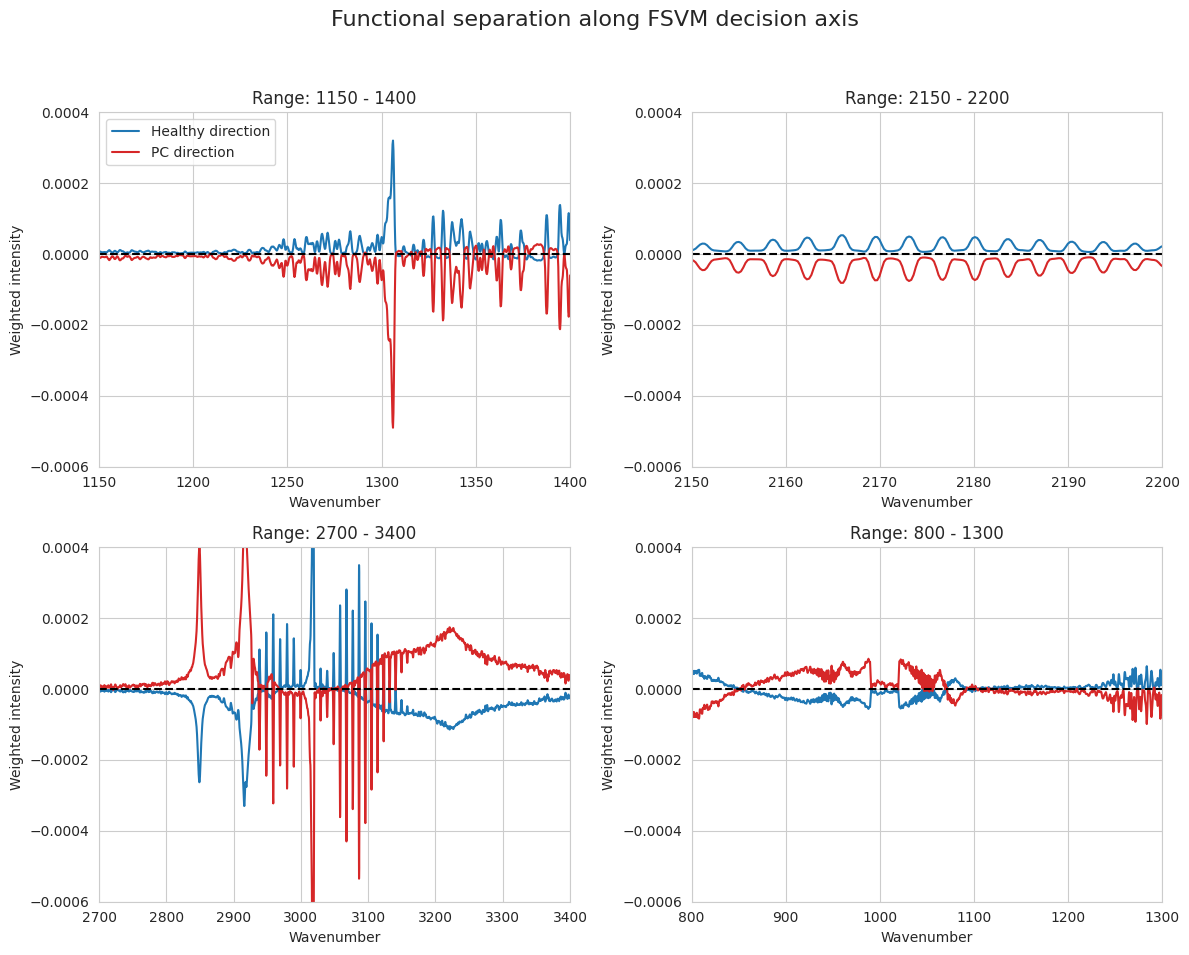

In [255]:
# Train linear SVM on full FPCA scores
clf_lin = SVC(kernel="linear", C=1.0)
clf_lin.fit(scores_K, y)

w = clf_lin.coef_.ravel()  # weights in FPCA space
phi_K = pca.components_[:K]

beta_t = np.dot(w, phi_K)

plt.figure(figsize=(8, 4))
plt.plot(wavenumbers, beta_t, color="black")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Wavenumber")
plt.ylabel("β(t)")
plt.xlim(1400, 1150)
plt.ylim(-0.0006, 0.0006)
plt.title("Estimated FSVM weight function")
plt.tight_layout()
plt.show()



proj = scores_K @ w

mean_proj_H = proj[y == 0].mean()
mean_proj_PC = proj[y == 1].mean()

recon_H = mean_proj_H * beta_t
recon_PC = mean_proj_PC * beta_t

plt.figure(figsize=(10, 5))
plt.plot(wavenumbers, recon_H, label="Healthy direction", color="tab:blue")
plt.plot(wavenumbers, recon_PC, label="PC direction", color="tab:red")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Wavenumber")
plt.ylabel("Weighted intensity")

plt.xlim(1150, 1400)
# plt.xlim(2700, 3400)
# plt.xlim(2150, 2200)
# plt.xlim(1150, 1400)
plt.ylim(-0.0006, 0.0004)


# plt.ylim(-0.001, 0.001)
plt.title("Functional separation along FSVM decision axis")
plt.legend()
plt.tight_layout()
plt.show() 


import matplotlib.pyplot as plt

# Define the x-limit ranges from your comments
x_limits = [
    (1150, 1400),
    (2150, 2200),
    (2700, 3400),
    (800, 1300)# Added a broad view as the 4th, or swap with another range
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, xlim in enumerate(x_limits):
    ax = axes[i]
    
    # Plotting the data
    ax.plot(wavenumbers, recon_H, label="Healthy direction", color="tab:blue")
    ax.plot(wavenumbers, recon_PC, label="PC direction", color="tab:red")
    
    # Formatting
    ax.axhline(0, color="black", linestyle="--")
    ax.set_xlim(xlim)
    ax.set_ylim(-0.0006, 0.0004) # Keeping ylim same for all
    
    ax.set_title(f"Range: {xlim[0]} - {xlim[1]}")
    ax.set_xlabel("Wavenumber")
    ax.set_ylabel("Weighted intensity")
    
    if i == 0:
        ax.legend()

plt.suptitle("Functional separation along FSVM decision axis", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [256]:
def midpt(x,y):
    return (y-x)/2
print(midpt(1150, 1400))
print(midpt(2150, 2200))
print(midpt(2700, 3400))
print(midpt(500, 570))

125.0
25.0
350.0
35.0


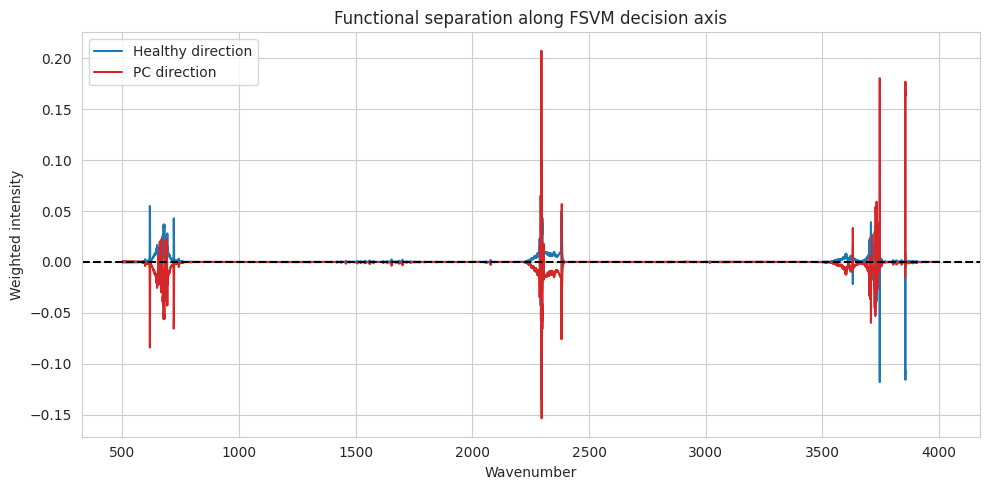

In [257]:
proj = scores_K @ w

mean_proj_H = proj[y == 0].mean()
mean_proj_PC = proj[y == 1].mean()

recon_H = mean_proj_H * beta_t
recon_PC = mean_proj_PC * beta_t

plt.figure(figsize=(10, 5))
plt.plot(wavenumbers, recon_H, label="Healthy direction", color="tab:blue")
plt.plot(wavenumbers, recon_PC, label="PC direction", color="tab:red")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Wavenumber")
plt.ylabel("Weighted intensity")

# plt.xlim(1150, 1400)
# plt.xlim(2700, 3400)
# plt.xlim(2150, 2200)
# plt.xlim(1150, 1400)
# plt.ylim(-0.0006, 0.0004)


# plt.ylim(-0.001, 0.001)
plt.title("Functional separation along FSVM decision axis")
plt.legend()
plt.tight_layout()
plt.show()


In [258]:
mean_proj_H

np.float64(-1.0275196252619734)

### Apply FSVM to chemically informed subdomains

In [259]:
import numpy as np
import pandas as pd

def extract_SR_matrix(df, center, width=15, horizontal = False):
    """
    Extract functional data matrix X (n_samples x n_wavenumbers)
    for a given spectral range.
    """
    wn_min, wn_max = center - width, center + width

    # assume df['wavenumber'] and df['intensity_baseline_corrected']
    # are stored as arrays / lists
    X = []
    wavenumbers_ref = None

    for _, row in df.iterrows():
        wn = np.array(row["wavenumber"])
        intensity = np.array(row["intensity_baseline_corrected"])

        mask = (wn >= wn_min) & (wn <= wn_max)

        if wavenumbers_ref is None:
            wavenumbers_ref = wn[mask]

        X.append(intensity[mask])
    if horizontal:
            return np.array(X), wavenumbers_ref

    return np.vstack(X), wavenumbers_ref

def fpca_train(X_train, n_fpc=5):
    """
    Perform FPCA on training functional data.
    """
    mean_func = X_train.mean(axis=0)
    Xc = X_train - mean_func

    # covariance in function space
    C = np.cov(Xc, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]

    eigvecs = eigvecs[:, idx[:n_fpc]]

    scores = Xc @ eigvecs
    return mean_func, eigvecs, scores

def fpca_project(X, mean_func, eigvecs):
    Xc = X - mean_func
    return Xc @ eigvecs

from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix

def fsvm_loocv_SR(X, y, n_fpc=5, C=1.0):
    loo = LeaveOneOut()
    decisions, y_true = [], []

    for train, test in loo.split(X):
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]

        mean_func, eigvecs, train_scores = fpca_train(X_train, n_fpc)
        test_scores = fpca_project(X_test, mean_func, eigvecs)

        svm = SVC(kernel="linear", C=C)
        svm.fit(train_scores, y_train)

        decisions.append(svm.decision_function(test_scores)[0])
        y_true.append(y_test[0])

    decisions = np.array(decisions)
    y_true = np.array(y_true)

    # orientation fix
    if decisions[y_true == 0].mean() > decisions[y_true == 1].mean():
        decisions *= -1

    y_pred = (decisions > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": (tp + tn) / len(y_true),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": 0.5 * (sensitivity + specificity),
        "decisions": decisions
    }
    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": (tp + tn) / len(y_true),
        "sensitivity": tp / (tp + fn) if (tp + fn) else 0,
        "specificity": tn / (tn + fp) if (tn + fp) else 0,
        "balanced_accuracy": 0.5 * (
            tp / (tp + fn) if (tp + fn) else 0 +
            tn / (tn + fp) if (tn + fp) else 0
        ),
        "decisions": decisions
    }



In [260]:
# List of SR centers only
SR_centers = [1005, 1050, 1170, 1190, 1203, 2170]

# Binary labels (PC vs H assumed already filtered upstream if needed)
y = (df["class"] == "PC").astype(int).values

results_per_sr = {}

print("Running FSVM per spectral region")
print("-----------------------------------------------------")

for c in SR_centers:
    print(f"SR center: {c} cm^-1")

    # Extract SR-specific matrix (function unchanged)
    X_sr, _ = extract_SR_matrix(df, c)

    # Run FSVM with LOOCV (function unchanged)
    # metrics = fsvm_loocv_SR(X_sr, y, n_fpc=5)
    res = repeated_stratified_kfold_fsvm(
        X_sr,
        y,
        feature_transform=None,
        k_values=(13, 14, 15),
        n_repeats=100,
        C=1.0,
        class_weight="balanced",
        random_state=42
    )
    for k, metrics in res.items():
    
        print(f"\n{k}-Fold CV")
        
        print("Accuracy:", np.mean(metrics["accuracy"]))
        print("Balanced Accuracy:", np.mean(metrics["balanced_accuracy"]))
        print("Sensitivity:", np.mean(metrics["sensitivity"]))
        print("Specificity:", np.mean(metrics["specificity"]))
    # Store results keyed by SR center
    results_per_sr[c] = res


Running FSVM per spectral region
-----------------------------------------------------
SR center: 1005 cm^-1

13-Fold CV
Accuracy: 0.34974358974358977
Balanced Accuracy: 0.5123076923076922
Sensitivity: 0.6923076923076924
Specificity: 0.33230769230769236

14-Fold CV
Accuracy: 0.40380952380952373
Balanced Accuracy: 0.5528571428571428
Sensitivity: 0.785714285714286
Specificity: 0.32

15-Fold CV
Accuracy: 0.464888888888889
Balanced Accuracy: 0.5986666666666666
Sensitivity: 0.8666666666666667
Specificity: 0.3306666666666666
SR center: 1050 cm^-1

13-Fold CV
Accuracy: 0.3582051282051282
Balanced Accuracy: 0.500576923076923
Sensitivity: 0.6199999999999998
Specificity: 0.3811538461538463

14-Fold CV
Accuracy: 0.4497619047619047
Balanced Accuracy: 0.5032142857142857
Sensitivity: 0.4492857142857144
Specificity: 0.5571428571428569

15-Fold CV
Accuracy: 0.5295555555555556
Balanced Accuracy: 0.5065
Sensitivity: 0.304
Specificity: 0.7090000000000001
SR center: 1170 cm^-1

13-Fold CV
Accuracy: 0.3497

In [261]:
for res in results_per_sr:
    for k, metrics in res.items():
    
        print(f"\n{k}-Fold CV")
        
        print("Accuracy:", np.mean(metrics["accuracy"]))
        print("Balanced Accuracy:", np.mean(metrics["balanced_accuracy"]))
        print("Sensitivity:", np.mean(metrics["sensitivity"]))
        print("Specificity:", np.mean(metrics["specificity"]))

AttributeError: 'int' object has no attribute 'items'

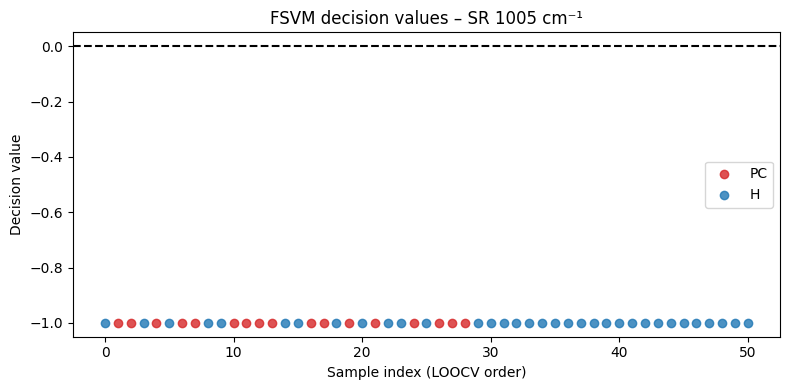

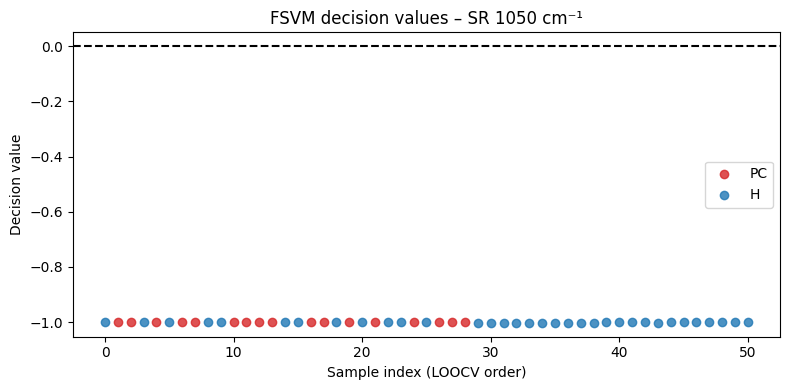

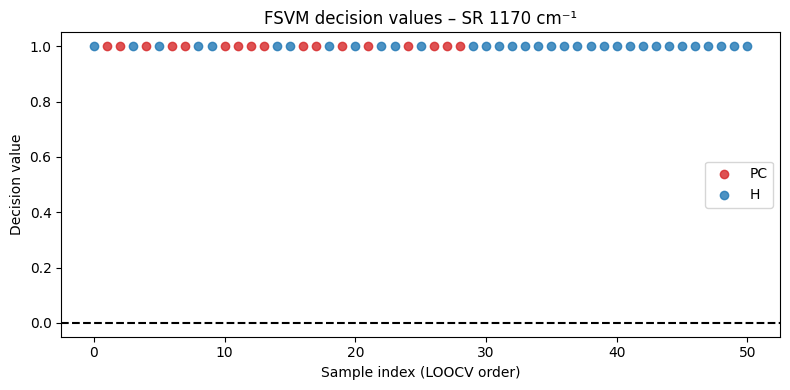

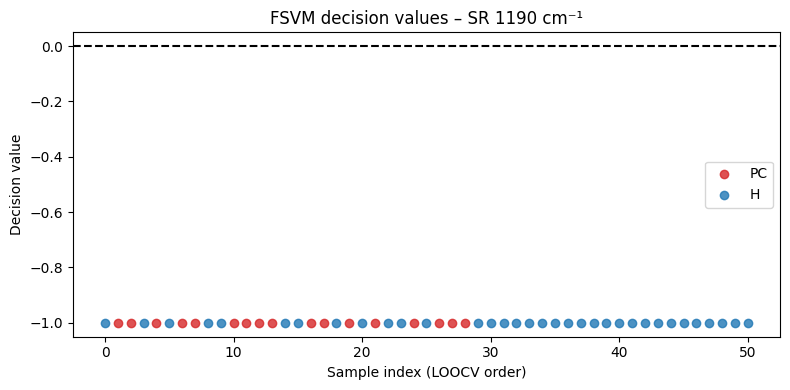

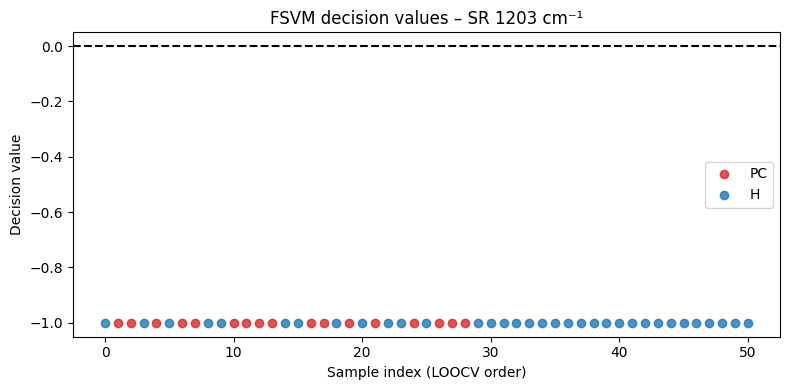

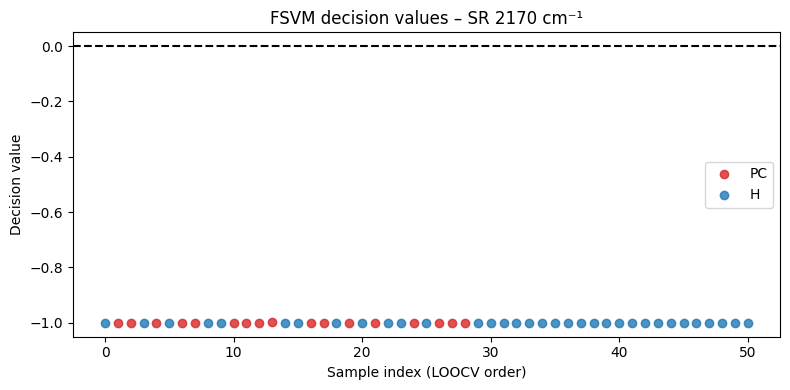

In [ ]:
for sr_center, metrics in results_per_sr.items():

    plot_decision_values(
        decisions=metrics["decisions"],
        y_true=metrics["y_true"],
        title=f"FSVM decision values – SR {sr_center} cm⁻¹"
    )


In [ ]:
import matplotlib.pyplot as plt

def plot_fpca_scores_2d(X, y, sr_center, n_fpc=2):
    mean_func, eigvecs, scores = fpca_train(X, n_fpc=n_fpc)

    plt.figure(figsize=(5, 4))
    for cls, label, color in [(0, "Healthy", "tab:blue"),
                              (1, "PC", "tab:red")]:
        idx = y == cls
        plt.scatter(
            scores[idx, 0],
            scores[idx, 1],
            label=label,
            alpha=0.8
        )

    plt.xlabel("FPC 1 score")
    plt.ylabel("FPC 2 score")
    plt.title(f"FPCA scores (SR {sr_center} cm⁻¹)")
    plt.legend()
    plt.tight_layout()
    plt.show()
for sr in [1005, 1050, 1170, 1190, 1203, 2170]:
 
    plot_fpca_scores_2d(X_sr, y, sr_center=sr)



IndexError: boolean index did not match indexed array along axis 0; size of axis is 51 but size of corresponding boolean axis is 43

<Figure size 500x400 with 0 Axes>

In [185]:
from mpl_toolkits.mplot3d import Axes3D

def plot_fpca_scores_3d(X, y, sr_center, n_fpc=5):
    mean_func, eigvecs, scores = fpca_train(X, n_fpc=n_fpc)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")

    for cls, label, color in [(0, "Healthy", "tab:blue"),
                              (1, "PC", "tab:red")]:
        idx = y == cls
        ax.scatter(
            scores[idx, 0],
            scores[idx, 1],
            scores[idx, 2],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel("FPC 1")
    ax.set_ylabel("FPC 2")
    ax.set_zlabel("FPC 3")
    ax.set_title(f"3D FPCA score space (SR {sr_center} cm⁻¹)")
    ax.legend()
    plt.tight_layout()
    plt.show()

for sr in [1005, 1050, 1170, 1190, 1203, 2170]:
    plot_fpca_scores_3d(X_sr, y, sr_center, n_fpc=3)


NameError: name 'sr_center' is not defined

In [186]:
def plot_functional_separation(
    X, y, sr_center, n_fpc=5
):
    mean_func, eigvecs, scores = fpca_train(X, n_fpc)

    svm = SVC(kernel="linear", C=1.0)
    svm.fit(scores, y)

    # FSVM functional weight
    w_fpc = svm.coef_.ravel()
    w_func = eigvecs @ w_fpc   # back to function space

    proj = X @ w_func



    # proj = scores_K @ w

    mean_proj_H = proj[y == 0].mean()
    mean_proj_PC = proj[y == 1].mean()

    recon_H = mean_proj_H * beta_t
    recon_PC = mean_proj_PC * beta_t

    plt.figure(figsize=(10, 5))
    plt.plot(wavenumbers, recon_H, label="Healthy direction", color="tab:blue")
    plt.plot(wavenumbers, recon_PC, label="PC direction", color="tab:red")
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Wavenumber")
    plt.ylabel("Weighted intensity")

    # plt.xlim(1150, 1400)
    plt.xlim(2700, 3400)
    # plt.xlim(2150, 2200)
    # plt.xlim(1150, 1400)
    plt.ylim(-0.0006, 0.0004)


    # plt.ylim(-0.001, 0.001)
    plt.title("Functional separation along FSVM decision axis")
    plt.legend()
    plt.tight_layout()
    plt.show()








    # plt.figure(figsize=(5, 4))
    # for cls, label, color in [(0, "Healthy", "tab:blue"),
    #                           (1, "PC", "tab:red")]:
    #     idx = y == cls
    #     plt.hist(
    #         proj[idx],
    #         bins=10,
    #         alpha=0.6,
    #         label=label,
    #         density=True
    #     )

    # plt.xlabel("Projection onto FSVM functional direction")
    # plt.ylabel("Density")
    # plt.title(f"Functional separation (SR {sr_center} cm⁻¹)")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()
plot_functional_separation(X_sr, y, sr_center=1005, n_fpc=5)



ValueError: Found input variables with inconsistent numbers of samples: [51, 43]

In [202]:
def extract_multi_SR_matrix(df, sr_centers, width=15):
    """
    Concatenates multiple SRs into a single functional domain
    """
    X_blocks = []
    wn_blocks = []

    for c in sr_centers:
        X_sr, wn_sr = extract_SR_matrix(df, c, width, horizontal = True)
        X_blocks.append(X_sr)
        wn_blocks.append(wn_sr)

    # Concatenate along wavenumber axis
    X_full = np.hstack(X_blocks)
    wn_full = np.concatenate(wn_blocks)

    return X_full, wn_full

def fsvm_loocv_multiSR(X, y, n_fpc=5, C=1):
    loo = LeaveOneOut()

    decisions = []
    y_true = []

    for train, test in loo.split(X):
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]

        # ---- FPCA (inside fold) ----
        mean_func = X_train.mean(axis=0)
        Xc = X_train - mean_func

        Cmat = np.cov(Xc, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(Cmat)

        idx = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx[:n_fpc]]

        # FPC scores
        scores_train = Xc @ eigvecs
        scores_test = (X_test - mean_func) @ eigvecs

        # ---- Linear SVM ----
        svm = SVC(kernel="linear", C=C, class_weight="balanced")
        svm.fit(scores_train, y_train)

        decision = svm.decision_function(scores_test)[0]
        decisions.append(decision)
        y_true.append(y_test[0])

    decisions = np.array(decisions)
    y_true = np.array(y_true)

    # orientation fix
    if decisions[y_true == 0].mean() > decisions[y_true == 1].mean():
        decisions = -decisions

    y_pred = (decisions > 0).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0

    return {
        "accuracy": (tp + tn) / len(y_true),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": 0.5 * (sensitivity + specificity),
        "decisions": decisions
    }

sr_centers = [530, 1005, 1050, 1170, 1190, 1203, 2170]

X_full, wn_full = extract_multi_SR_matrix(df_bin, sr_centers)

results = fsvm_loocv_multiSR(X_full, y, n_fpc=2, C=1)

print(results)


{'accuracy': np.float64(1.0), 'sensitivity': np.float64(1.0), 'specificity': np.float64(1.0), 'balanced_accuracy': np.float64(1.0), 'decisions': array([-0.9051454 ,  0.65634973,  0.6050453 , -0.88545686,  0.63250227,
        0.56484767,  0.58260854,  0.64095528,  0.62955261,  0.65505689,
        0.60204508, -0.88031321, -0.9258323 ,  0.63794734,  0.63453455,
        0.65244663,  0.63821133,  0.65876472,  0.63434674,  0.6451142 ,
        0.63992097, -0.59636737, -0.58975724, -0.59669397, -0.60697526,
       -0.5989849 , -0.59663872, -0.59451756, -0.6048773 , -0.59180003,
       -0.58008491, -1.06602092, -1.09769829, -1.11382799, -1.04106738,
       -0.61572046, -0.91051407, -0.9051454 , -0.88545686, -0.88031321,
       -0.9258323 , -0.89724428, -0.89952055])}


In [200]:
from sklearn.svm import SVC

def fit_linear_fsvm_multiSR(X, y, n_fpc=6, C=1.0):
    """
    Fit linear FSVM on full data (no CV) for functional interpretation
    """
    # ---- FPCA ----
    mean_func = X.mean(axis=0)
    Xc = X - mean_func

    Cmat = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(Cmat)
    idx = np.argsort(eigvals)[::-1][:n_fpc]
    eigvecs = eigvecs[:, idx]

    scores = Xc @ eigvecs

    # ---- Linear SVM ----
    svm = SVC(kernel="linear", C=C)
    svm.fit(scores, y)

    # FSVM functional weight
    w_fpc = svm.coef_.ravel()
    w_func = eigvecs @ w_fpc

    mean_H = X[y == 0].mean(axis=0)
    mean_PC = X[y == 1].mean(axis=0)

    return w_func, mean_H, mean_PC


import matplotlib.pyplot as plt

def plot_fsvm_curves_multiSR(
    X, y, wn_full, sr_centers, n_fpc=5
):
    w_func, mean_H, mean_PC = fit_linear_fsvm_multiSR(
        X, y, n_fpc=n_fpc
    )

    f_H = mean_H * w_func
    f_PC = mean_PC * w_func

    plt.figure(figsize=(9, 4))
    plt.plot(wn_full, f_H, label="Healthy", linewidth=2)
    plt.plot(wn_full, f_PC, label="PC", linewidth=2)

    plt.axhline(0, color="black", linestyle="--", linewidth=1)

    # Mark SR boundaries
    for c in sr_centers:
        plt.axvline(c, color="gray", linestyle=":", alpha=0.4)

    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("FSVM-weighted intensity")
    plt.title("FSVM functional separation – concatenated SRs")
    plt.legend()
    plt.tight_layout()
    plt.show()

# plot_fsvm_curves_multiSR(
#     X=X_full,
#     y=y,
#     wn_full=wn_full,
#     sr_centers=sr_centers,
#     n_fpc=2
# )

# plt.figure(figsize=(9, 4))
# plt.plot(
#     wn_full,
#     f_PC - f_H,
#     color="black",
#     linewidth=2
# )

# for c in sr_centers:
#     plt.axvline(c, color="gray", linestyle=":", alpha=0.4)

# plt.axhline(0, linestyle="--")
# plt.xlabel("Wavenumber (cm⁻¹)")
# plt.ylabel("PC − H (FSVM contribution)")
# plt.title("FSVM discriminative function – concatenated SRs")
# plt.tight_layout()
# plt.show()


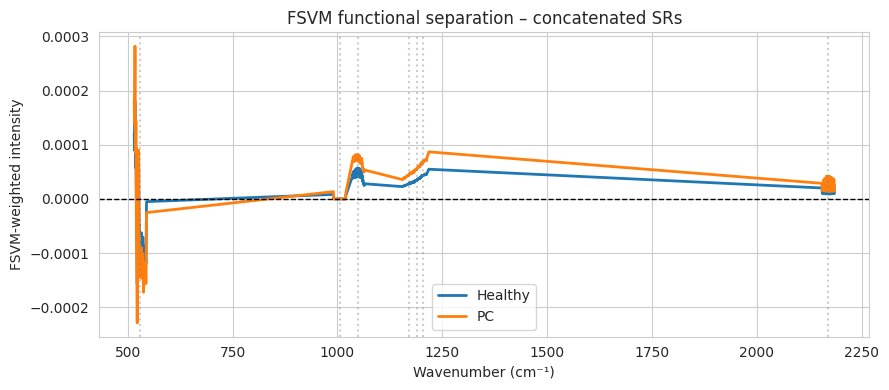

In [201]:
plot_fsvm_curves_multiSR(
    X_full, y, wn_full, sr_centers, n_fpc=5
)